In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df =pd.read_csv(r'C:\Users\DELL\Downloads\train.csv\train.csv', encoding ='latin1')

In [3]:
df.shape

(9800, 18)

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
df['Order Date'] =pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] =pd.to_datetime(df['Ship Date'], dayfirst=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [7]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

Only `Postal Code` has missing values (11 out of 9,800 rows, ~0.1%). 
Since geographic analysis in this project uses City/State/Region instead, 
these missing values were left as-is and do not affect the analysis.

In [8]:
df['Sales'].mode()

0    12.96
Name: Sales, dtype: float64

In [9]:
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales
count,9800.000000,9800,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-01 05:13:51.673469440,2017-05-05 04:17:52.653061120,55273.322403,230.769059
min,1.000000,2015-01-03 00:00:00,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-24 00:00:00,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-26 00:00:00,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-15 00:00:00,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2018-12-30 00:00:00,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,NaN,32041.223413,626.651875


Average sale is 230.77 dollars, but the median is only 54.49 dollars, indicating a right skewed distribution driven by a small number of high value transactions with a maximum of 22638.48 dollars. Most individual sales are modest.

In [10]:
df ['Order Month'] =df['Order Date'].dt.to_period('M')

In [11]:
monthly_sales=df.groupby('Order Month')['Sales'].sum()

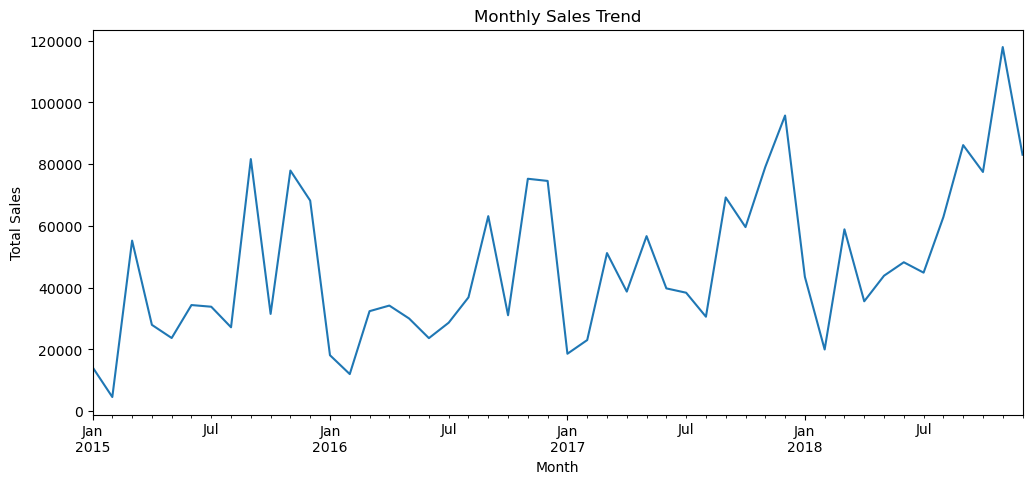

In [12]:
plt.figure(figsize=(12,5))
monthly_sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.show()

Monthly sales show clear seasonality with repeated peaks and troughs, alongside an overall upward trend from 2015 to 2018. The highest spike occurs near the end of 2018, suggesting strong late-year demand, possibly holiday-driven."

In [13]:
df['Segment'].value_counts()

Segment
Consumer       5101
Corporate      2953
Home Office    1746
Name: count, dtype: int64

In [14]:
df.groupby('Segment')['Sales'].sum()

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

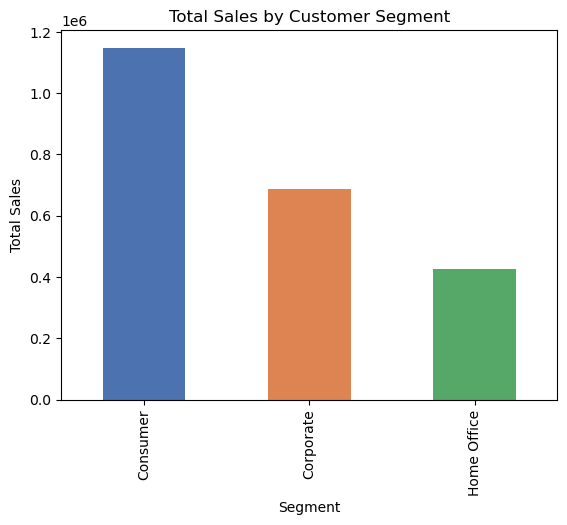

In [15]:
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Total Sales by Customer Segment')
plt.xlabel('Segment')
plt.ylabel('Total Sales')
plt.show()


Note: This dataset does not include customer age or gender fields, so demographic 
analysis by age group/gender is not possible. Customer Segment (Consumer/Corporate/
Home Office) is used instead as the closest available customer-grouping dimension.


Consumer segment generates the highest total sales at 1.14 million dollars, nearly 1.7 times Corporate at 0.68 million dollars and almost 3 times Home Office at 0.42 million dollars. This indicates individual consumers are the dominant revenue driver, not business accounts.

In [16]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)
print(top_products)

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


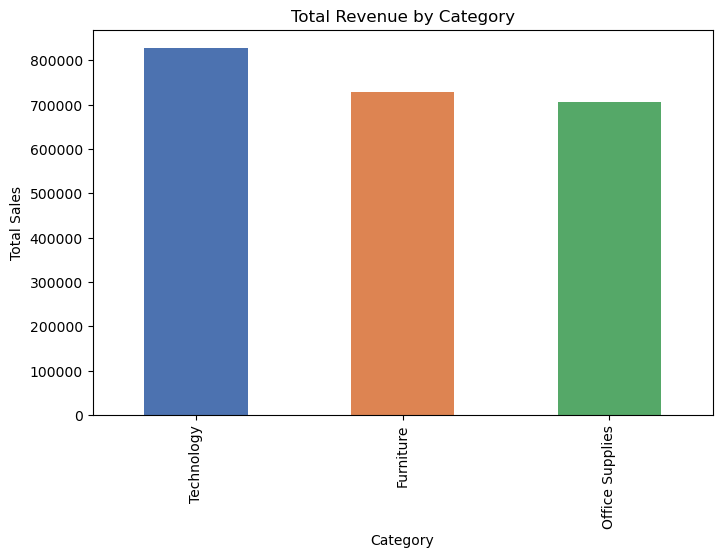

In [17]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
category_sales.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868'])
plt.title('Total Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.show()

Product Analysis

The top selling products by revenue are dominated by high value Technology and Furniture items rather than low cost everyday supplies, for example the Canon imageCLASS 2200 Advanced Copier at 61599 dollars, Cisco TelePresence System EX90 at 27453 dollars, and Fellowes PB500 Binding Machine at 27453 dollars. This shows Technology's strong category performance is driven by a small number of expensive products, not high sales volume.

Category revenue is fairly balanced overall. Technology leads at about 830000 dollars, followed by Furniture at about 700000 dollars and Office Supplies at about 670000 dollars, only about a 20 percent gap top to bottom. This contrasts with the Segment analysis, where one group, Consumer, clearly dominated revenue.

In [18]:
df.select_dtypes(include='number').columns

Index(['Row ID', 'Postal Code', 'Sales'], dtype='object')

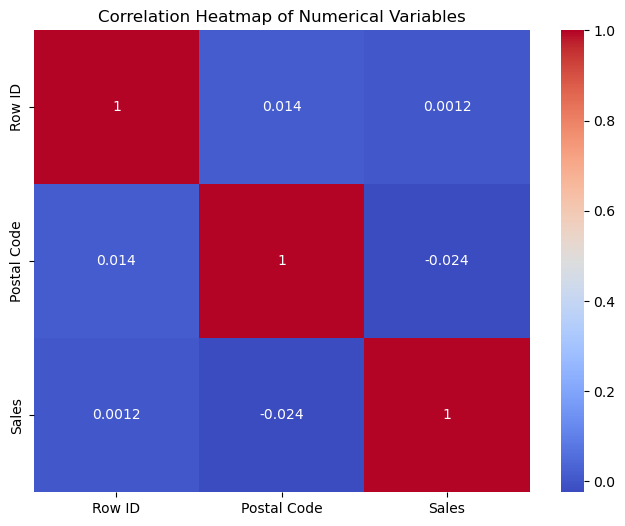

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Variables')
plt.show()

The correlation heatmap shows no meaningful relationships among the numeric columns. Row ID and Postal Code are identifier or location codes rather than measurable quantities, so their near zero correlation with Sales (0.0012 and negative 0.024) is expected and not meaningful. This dataset does not include other numeric fields such as Quantity, Discount, or Profit, which limits deeper correlation analysis.

In [20]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Order Month'],
      dtype='object')

In [21]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


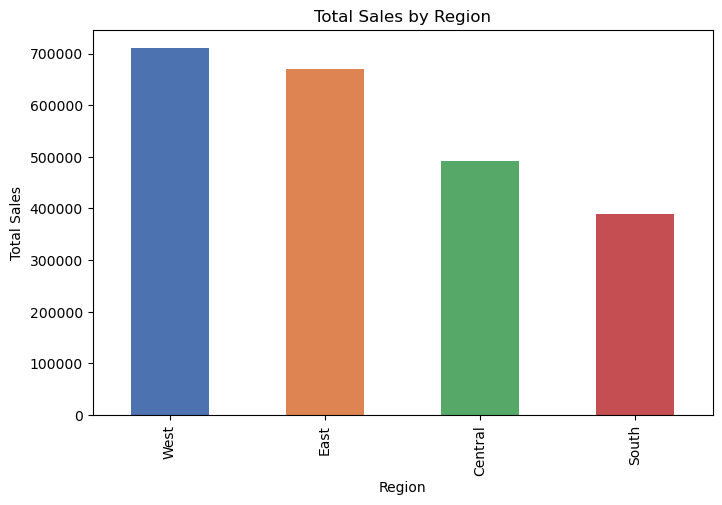

In [22]:
plt.figure(figsize=(8,5))
region_sales.plot(kind='bar', color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.show()

Sales by region show a clear split. West at 710219.68 dollars and East at 669518.73 dollars lead the way, while Central at 492646.91 dollars and South at 389151.46 dollars trail meaningfully behind. This is a genuinely new pattern not captured by the Segment or Category analysis, and suggests West and East regions may warrant continued investment while Central and South could be investigated for underperformance.

Conclusion and Recommendations

This analysis of the Superstore sales dataset revealed several clear patterns across time, customer segments, products, and regions.

1. Increase inventory and staffing ahead of late-year demand. Monthly sales show repeated seasonal peaks alongside an overall upward trend from 2015 to 2018, with the strongest spike occurring near the end of the year. The business should prepare stock levels and staffing in advance of this period rather than reacting to it.

2. Prioritize marketing and retention efforts on the Consumer segment. Consumer generates about 1.14 million dollars in sales, nearly 1.7 times Corporate and almost 3 times Home Office. Since individual consumers, not businesses, drive the majority of revenue, campaigns and loyalty programs should be weighted toward this group rather than split evenly across all three segments.

3. Investigate underperformance in the Central and South regions. West and East regions lead in total sales, at 710219.68 dollars and 669518.73 dollars respectively, while Central and South trail meaningfully behind at 492646.91 dollars and 389151.46 dollars. Since this pattern is not explained by product or segment data alone, further investigation into regional demand, local competition, or distribution logistics is recommended before deciding whether to invest more heavily there or scale back.

4. Continue supporting high value Technology products while monitoring Office Supplies volume. Technology leads category revenue at about 830000 dollars, driven by a small number of expensive products such as the Canon imageCLASS copier at 61599 dollars. Office Supplies revenue is close behind despite lower individual prices, suggesting high transaction volume. Both product strategies, high value and high volume, are currently contributing meaningfully and should be maintained rather than favoring one over the other.

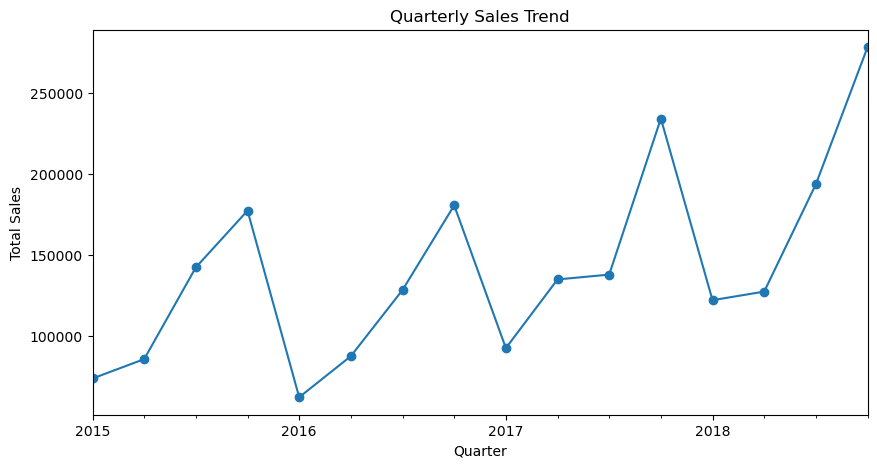

In [23]:
quarterly_sales = df.groupby(df['Order Date'].dt.to_period('Q'))['Sales'].sum()
plt.figure(figsize=(10,5))
quarterly_sales.plot(kind='line', marker='o')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Sales')
plt.show()
